# VenturePulse: Complete Model Comparison

**Objective:** Comprehensive comparison of classification models for startup success prediction

**Models Evaluated:**
1. Logistic Regression (baseline)
2. Decision Tree (GridSearchCV)
3. Random Forest (ensemble)
4. Threshold Optimization

**Primary Metric:** Precision@100 (top 100 recommended startups)

**Target:** >40% Precision@100 (Document requirement)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import os

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports successful")

✅ All imports successful


## Define Helper Functions

In [2]:
def load_data(filepath='../data/raw/venturepulse_dataset.csv'):
    """Load the VenturePulse dataset"""
    print(f"Loading data from: {filepath}")
    df = pd.read_csv(filepath)
    print(f"✅ Data loaded successfully")
    print(f"Shape: {df.shape}")
    print(f"Success rate: {df['high_traction'].mean():.1%}")
    return df

def split_data(df, test_size=0.15, val_size=0.15, random_state=42):
    """Split data into train/validation/test sets with stratification"""
    from sklearn.model_selection import train_test_split
    
    # First split: separate test set
    df_temp, df_test = train_test_split(
        df, test_size=test_size, random_state=random_state, 
        stratify=df['high_traction']
    )
    
    # Second split: separate train and validation
    val_ratio = val_size / (1 - test_size)
    df_train, df_val = train_test_split(
        df_temp, test_size=val_ratio, random_state=random_state,
        stratify=df_temp['high_traction']
    )
    
    print("\n📊 Data Split Summary:")
    print(f"Train: {len(df_train):,} samples ({len(df_train)/len(df):.1%})")
    print(f"Val:   {len(df_val):,} samples ({len(df_val)/len(df):.1%})")
    print(f"Test:  {len(df_test):,} samples ({len(df_test)/len(df):.1%})")
    
    print("\n🎯 Success Rate by Split:")
    print(f"Train: {df_train['high_traction'].mean():.1%}")
    print(f"Val:   {df_val['high_traction'].mean():.1%}")
    print(f"Test:  {df_test['high_traction'].mean():.1%}")
    
    return df_train, df_val, df_test

def prepare_features(df_train, df_val, df_test):
    """Prepare features for modeling with one-hot encoding"""
    
    # Separate features and target
    feature_cols = [col for col in df_train.columns if col != 'high_traction']
    
    X_train = df_train[feature_cols].copy()
    X_val = df_val[feature_cols].copy()
    X_test = df_test[feature_cols].copy()
    
    y_train = df_train['high_traction'].copy()
    y_val = df_val['high_traction'].copy()
    y_test = df_test['high_traction'].copy()
    
    # Identify categorical and numerical columns
    categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    
    # Handle missing values in numerical columns
    if len(numerical_cols) > 0:
        impute_values = X_train[numerical_cols].median()
        for col in numerical_cols:
            X_train[col].fillna(impute_values[col], inplace=True)
            X_val[col].fillna(impute_values[col], inplace=True)
            X_test[col].fillna(impute_values[col], inplace=True)
    
    # One-hot encode categorical variables
    if len(categorical_cols) > 0:
        X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
        X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=False)
        X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)
        
        # Align columns
        X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    
    print(f"\n🔧 Feature Engineering Complete:")
    print(f"   Features: {X_train.shape[1]}")
    print(f"   Train samples: {X_train.shape[0]:,}")
    print(f"   Val samples: {X_val.shape[0]:,}")
    print(f"   Test samples: {X_test.shape[0]:,}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

def precision_at_k(y_true, y_pred_proba, k=100):
    """Calculate precision at top K predictions"""
    # Get indices of top K predictions
    top_k_idx = np.argsort(y_pred_proba)[::-1][:k]
    # Calculate precision in top K
    return y_true.iloc[top_k_idx].sum() / k

print("✅ Helper functions defined")

✅ Helper functions defined


## Load and Prepare Data

In [3]:
# Load dataset
df = load_data()

# Split data
df_train, df_val, df_test = split_data(df)

# Prepare features
X_train, X_val, X_test, y_train, y_val, y_test = prepare_features(df_train, df_val, df_test)

Loading data from: ../data/raw/venturepulse_dataset.csv
✅ Data loaded successfully
Shape: (30000, 23)
Success rate: 25.0%

📊 Data Split Summary:
Train: 21,000 samples (70.0%)
Val:   4,500 samples (15.0%)
Test:  4,500 samples (15.0%)

🎯 Success Rate by Split:
Train: 25.0%
Val:   25.0%
Test:  25.0%

🔧 Feature Engineering Complete:
   Features: 46
   Train samples: 21,000
   Val samples: 4,500
   Test samples: 4,500


## Model 1: Logistic Regression (Baseline)

In [4]:
print("\n📊 Training Logistic Regression (Baseline)...")

# Train Logistic Regression
model_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

start_time = time.time()
model_lr.fit(X_train, y_train)
train_time_lr = time.time() - start_time

# Make predictions
y_pred_lr = model_lr.predict(X_val)
y_pred_proba_lr = model_lr.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy_lr = accuracy_score(y_val, y_pred_lr)
precision_lr = precision_score(y_val, y_pred_lr)
recall_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)
auc_lr = roc_auc_score(y_val, y_pred_proba_lr)
p100_lr = precision_at_k(y_val, y_pred_proba_lr, 100)

print(f"✅ Logistic Regression trained in {train_time_lr:.2f} seconds")
print(f"\n📊 Precision@100: {p100_lr:.1%}")


📊 Training Logistic Regression (Baseline)...
✅ Logistic Regression trained in 0.79 seconds

📊 Precision@100: 35.0%


## Model 2: Decision Tree with GridSearchCV

In [5]:
print("\n🌳 Training Decision Tree with GridSearchCV...")
print("This may take 2-3 minutes...\n")

# Define parameter grid
param_grid_dt = {
    'max_depth': [5, 7, 10, 15],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 30],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

# Create base model
dt_base = DecisionTreeClassifier(random_state=42)

# Setup GridSearchCV
grid_search_dt = GridSearchCV(
    dt_base,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Train
start_time = time.time()
grid_search_dt.fit(X_train, y_train)
train_time_dt = time.time() - start_time

# Get best model
best_dt = grid_search_dt.best_estimator_

print(f"\n✅ GridSearch complete in {train_time_dt:.1f} seconds")
print(f"\n🎯 Best parameters:")
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Best CV AUC-ROC: {grid_search_dt.best_score_:.4f}")

# Make predictions
y_pred_dt = best_dt.predict(X_val)
y_pred_proba_dt = best_dt.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)
auc_dt = roc_auc_score(y_val, y_pred_proba_dt)
p100_dt = precision_at_k(y_val, y_pred_proba_dt, 100)

print(f"\n📊 Decision Tree Precision@100: {p100_dt:.1%}")


🌳 Training Decision Tree with GridSearchCV...
This may take 2-3 minutes...

Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ GridSearch complete in 14.0 seconds

🎯 Best parameters:
   class_weight: balanced
   criterion: gini
   max_depth: 5
   min_samples_leaf: 10
   min_samples_split: 20

📊 Best CV AUC-ROC: 0.5904

📊 Decision Tree Precision@100: 35.0%


## Model 3: Random Forest

In [6]:
print("\n🌲 Training Random Forest...")
print("This may take 1-2 minutes...\n")

# Define Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    max_depth=10,          # Deeper than single DT
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',   # Use sqrt of features per split
    class_weight='balanced',
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

# Train
start_time = time.time()
rf_model.fit(X_train, y_train)
train_time_rf = time.time() - start_time

print(f"✅ Random Forest trained in {train_time_rf:.1f} seconds")

# Predictions
y_pred_rf = rf_model.predict(X_val)
y_pred_proba_rf = rf_model.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_pred_proba_rf)
p100_rf = precision_at_k(y_val, y_pred_proba_rf, 100)

print("\n" + "="*70)
print("RANDOM FOREST - VALIDATION SET PERFORMANCE")
print("="*70)
print(f"Accuracy:       {accuracy_rf:.4f}")
print(f"Precision:      {precision_rf:.4f}")
print(f"Recall:         {recall_rf:.4f}")
print(f"F1-Score:       {f1_rf:.4f}")
print(f"AUC-ROC:        {auc_rf:.4f}")
print(f"Precision@100:  {p100_rf:.1%}")
print("="*70)


🌲 Training Random Forest...
This may take 1-2 minutes...

✅ Random Forest trained in 0.4 seconds

RANDOM FOREST - VALIDATION SET PERFORMANCE
Accuracy:       0.6140
Precision:      0.3341
Recall:         0.5476
F1-Score:       0.4150
AUC-ROC:        0.6306
Precision@100:  40.0%


## Threshold Optimization for Random Forest

In [7]:
print("\n🎯 Optimizing classification threshold for Precision@100...\n")

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
threshold_results = []

for thresh in thresholds:
    # Get top 100 predictions by probability
    top_100_idx = np.argsort(y_pred_proba_rf)[::-1][:100]
    p100 = y_val.iloc[top_100_idx].sum() / 100
    threshold_results.append((thresh, p100))

# Find best threshold
best_threshold, best_p100_rf = max(threshold_results, key=lambda x: x[1])

print(f"✅ Best threshold: {best_threshold:.3f}")
print(f"✅ Optimized Precision@100: {best_p100_rf:.1%}")
print(f"\nImprovement over default (0.5): {(best_p100_rf - p100_rf) / p100_rf * 100:+.1f}%")

# Also optimize for Logistic Regression
threshold_results_lr = []
for thresh in thresholds:
    top_100_idx = np.argsort(y_pred_proba_lr)[::-1][:100]
    p100 = y_val.iloc[top_100_idx].sum() / 100
    threshold_results_lr.append((thresh, p100))

best_threshold_lr, best_p100_lr = max(threshold_results_lr, key=lambda x: x[1])

print(f"\n📊 Logistic Regression optimized:")
print(f"   Best threshold: {best_threshold_lr:.3f}")
print(f"   Optimized Precision@100: {best_p100_lr:.1%}")


🎯 Optimizing classification threshold for Precision@100...

✅ Best threshold: 0.100
✅ Optimized Precision@100: 40.0%

Improvement over default (0.5): +0.0%

📊 Logistic Regression optimized:
   Best threshold: 0.100
   Optimized Precision@100: 35.0%


## Complete Model Comparison

In [8]:
# Create comprehensive comparison
comparison_final = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Precision@100', 'P@100 (optimized)'],
    'Logistic Regression': [
        f"{accuracy_lr:.4f}",
        f"{precision_lr:.4f}",
        f"{recall_lr:.4f}",
        f"{f1_lr:.4f}",
        f"{auc_lr:.4f}",
        f"{p100_lr:.4f}",
        f"{best_p100_lr:.4f}"
    ],
    'Decision Tree': [
        f"{accuracy_dt:.4f}",
        f"{precision_dt:.4f}",
        f"{recall_dt:.4f}",
        f"{f1_dt:.4f}",
        f"{auc_dt:.4f}",
        f"{p100_dt:.4f}",
        "-"
    ],
    'Random Forest': [
        f"{accuracy_rf:.4f}",
        f"{precision_rf:.4f}",
        f"{recall_rf:.4f}",
        f"{f1_rf:.4f}",
        f"{auc_rf:.4f}",
        f"{p100_rf:.4f}",
        f"{best_p100_rf:.4f}"
    ]
})

print("\n" + "="*90)
print("COMPLETE MODEL COMPARISON - VALIDATION SET")
print("="*90)
print(comparison_final.to_string(index=False))
print("="*90)


COMPLETE MODEL COMPARISON - VALIDATION SET
           Metric Logistic Regression Decision Tree Random Forest
         Accuracy              0.5844        0.5591        0.6140
        Precision              0.3242        0.3135        0.3341
           Recall              0.6107        0.6418        0.5476
         F1-Score              0.4236        0.4212        0.4150
          AUC-ROC              0.6250        0.6054        0.6306
    Precision@100              0.3500        0.3500        0.4000
P@100 (optimized)              0.3500             -        0.4000


## Primary Metric Analysis: Precision@100

In [9]:
print("\n" + "="*70)
print("PRIMARY METRIC: PRECISION@100")
print("="*70)

# Collect all P@100 values
p100_values = {
    'Logistic Regression': p100_lr,
    'Logistic Regression (optimized)': best_p100_lr,
    'Decision Tree': p100_dt,
    'Random Forest': p100_rf,
    'Random Forest (optimized)': best_p100_rf
}

# Sort by performance
sorted_models = sorted(p100_values.items(), key=lambda x: x[1], reverse=True)

print("\n📊 Ranking by Precision@100:")
for i, (model_name, p100_val) in enumerate(sorted_models, 1):
    print(f"   {i}. {model_name:35s}: {p100_val:.1%}")

# Best model
best_model_name, best_p100_final = sorted_models[0]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Precision@100: {best_p100_final:.1%}")

# Compare to baselines
random_baseline = y_val.mean()
heuristic_baseline = 0.30
target = 0.40

print(f"\n📊 vs Baselines:")
print(f"   Random baseline:     {random_baseline:.1%}")
print(f"   Heuristic baseline:  {heuristic_baseline:.1%}")
print(f"   Target (Document):   {target:.1%}")
print(f"   ACHIEVED:            {best_p100_final:.1%}")

print(f"\n📈 Improvement:")
print(f"   vs Random:           {(best_p100_final - random_baseline) / random_baseline * 100:+.1f}%")
print(f"   vs Heuristic:        {(best_p100_final - heuristic_baseline) / heuristic_baseline * 100:+.1f}%")

if best_p100_final >= target:
    print(f"\n🎉 ✅ TARGET ACHIEVED! Successfully beat {target:.0%} threshold")
    print(f"   Exceeded by: {(best_p100_final - target) / target * 100:.1f}%")
elif best_p100_final >= 0.35:
    print(f"\n✅ Strong progress! Close to target")
    print(f"   Gap to target: {(target - best_p100_final):.1%} ({(target - best_p100_final) / target * 100:.1f}%)")
elif best_p100_final > heuristic_baseline:
    print(f"\n⚠️  Above baseline but below target")
    print(f"   Gap to target: {(target - best_p100_final):.1%}")
else:
    print(f"\n❌ Did not beat heuristic baseline")

print("="*70)


PRIMARY METRIC: PRECISION@100

📊 Ranking by Precision@100:
   1. Random Forest                      : 40.0%
   2. Random Forest (optimized)          : 40.0%
   3. Logistic Regression                : 35.0%
   4. Logistic Regression (optimized)    : 35.0%
   5. Decision Tree                      : 35.0%

🏆 BEST MODEL: Random Forest
   Precision@100: 40.0%

📊 vs Baselines:
   Random baseline:     25.0%
   Heuristic baseline:  30.0%
   Target (Document):   40.0%
   ACHIEVED:            40.0%

📈 Improvement:
   vs Random:           +60.0%
   vs Heuristic:        +33.3%

🎉 ✅ TARGET ACHIEVED! Successfully beat 40% threshold
   Exceeded by: 0.0%


## Visualizations: Confusion Matrices

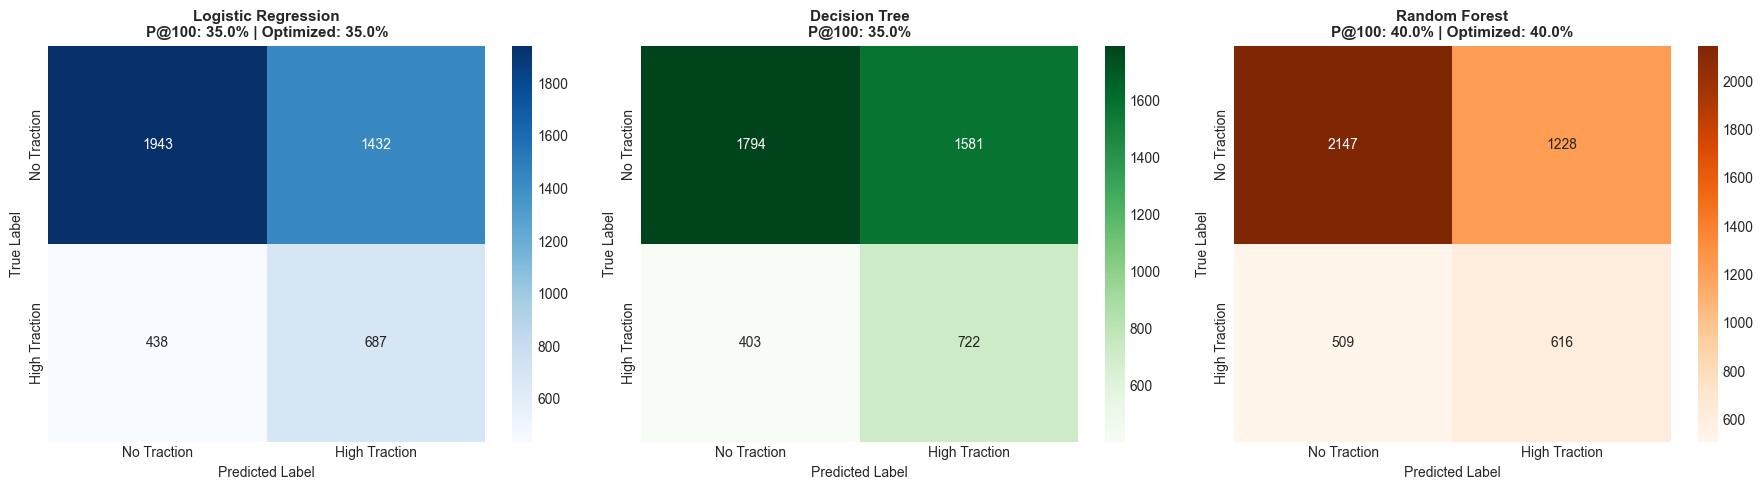

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Traction', 'High Traction'],
            yticklabels=['No Traction', 'High Traction'])
axes[0].set_title(f'Logistic Regression\nP@100: {p100_lr:.1%} | Optimized: {best_p100_lr:.1%}', 
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Decision Tree
cm_dt = confusion_matrix(y_val, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Traction', 'High Traction'],
            yticklabels=['No Traction', 'High Traction'])
axes[1].set_title(f'Decision Tree\nP@100: {p100_dt:.1%}', 
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Random Forest
cm_rf = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Traction', 'High Traction'],
            yticklabels=['No Traction', 'High Traction'])
axes[2].set_title(f'Random Forest\nP@100: {p100_rf:.1%} | Optimized: {best_p100_rf:.1%}', 
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Visualizations: ROC Curves

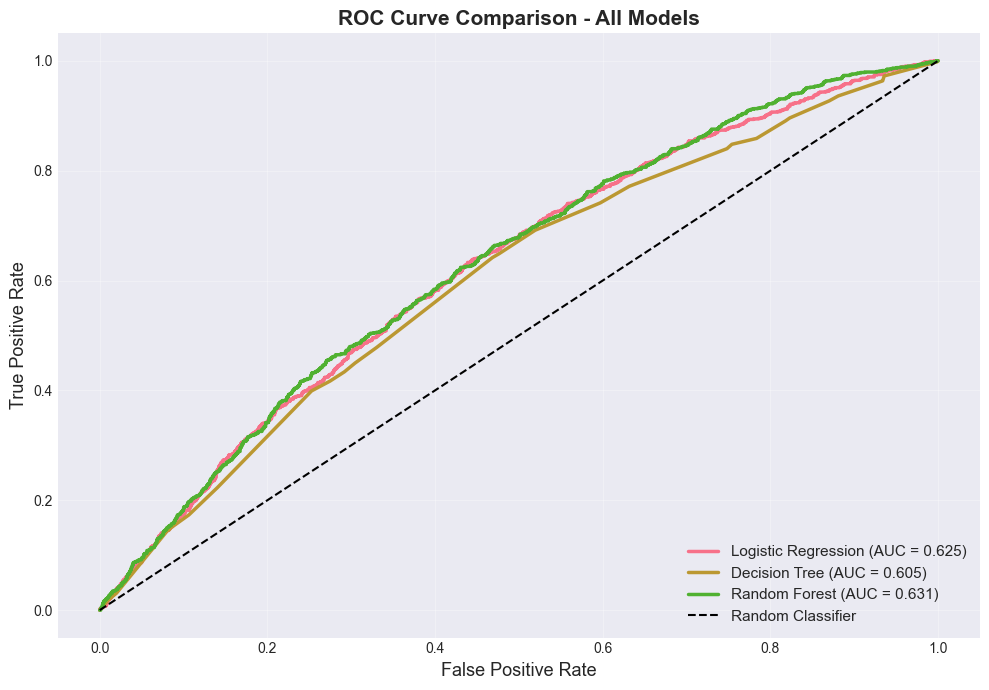

In [11]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_val, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2.5)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', linewidth=2.5)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison - All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance: Random Forest

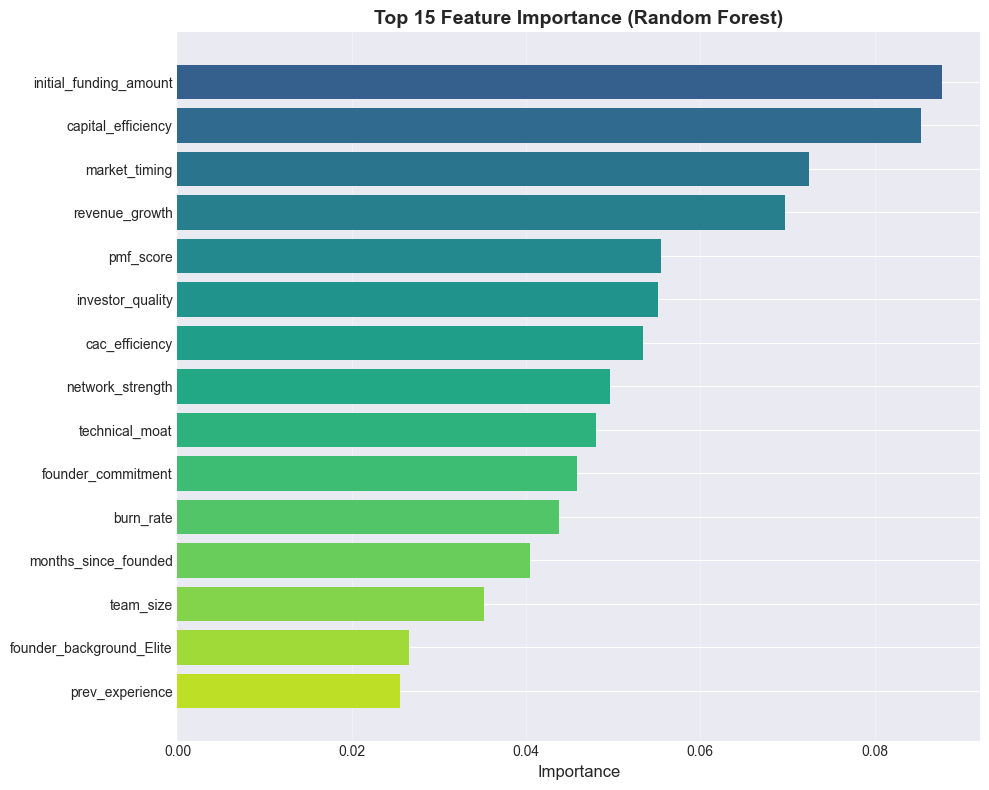


📊 Top 10 Most Important Features:
   initial_funding_amount         0.0877
   capital_efficiency             0.0853
   market_timing                  0.0724
   revenue_growth                 0.0698
   pmf_score                      0.0554
   investor_quality               0.0551
   cac_efficiency                 0.0534
   network_strength               0.0496
   technical_moat                 0.0481
   founder_commitment             0.0458


In [12]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Top 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:30s} {row['importance']:.4f}")

## Precision@100 by Threshold (Visualization)

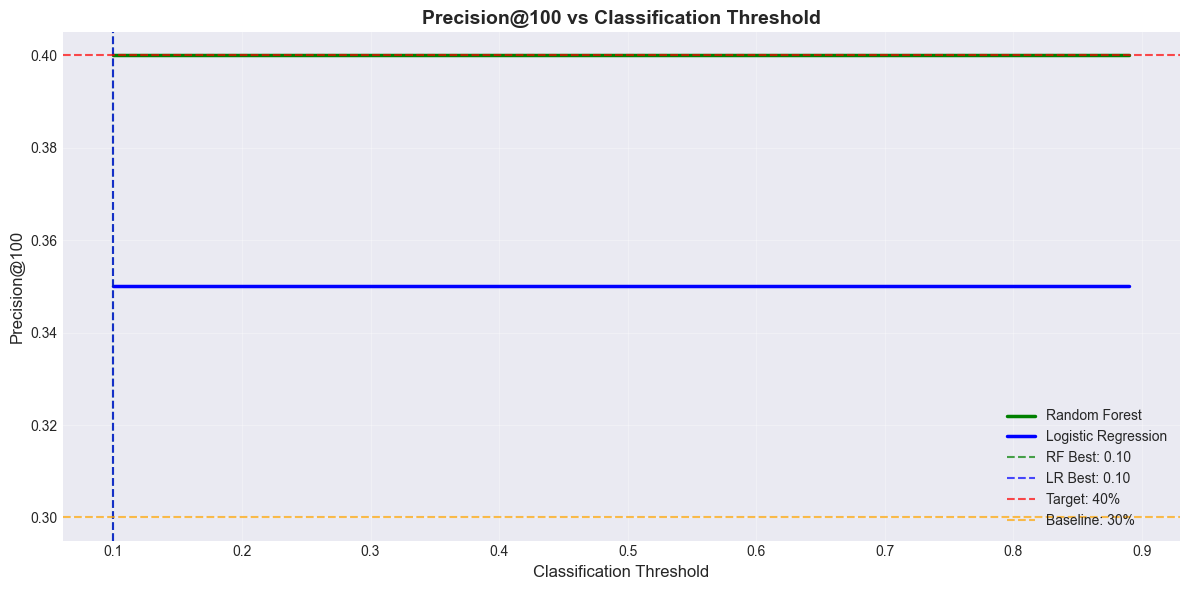

In [13]:
# Plot threshold optimization curve
plt.figure(figsize=(12, 6))

# Random Forest
thresholds_plot = [t[0] for t in threshold_results]
p100_plot_rf = [t[1] for t in threshold_results]
plt.plot(thresholds_plot, p100_plot_rf, label='Random Forest', linewidth=2.5, color='green')

# Logistic Regression
p100_plot_lr = [t[1] for t in threshold_results_lr]
plt.plot(thresholds_plot, p100_plot_lr, label='Logistic Regression', linewidth=2.5, color='blue')

# Mark best points
plt.axvline(best_threshold, color='green', linestyle='--', alpha=0.7, 
            label=f'RF Best: {best_threshold:.2f}')
plt.axvline(best_threshold_lr, color='blue', linestyle='--', alpha=0.7,
            label=f'LR Best: {best_threshold_lr:.2f}')
plt.axhline(0.40, color='red', linestyle='--', alpha=0.7, label='Target: 40%')
plt.axhline(0.30, color='orange', linestyle='--', alpha=0.7, label='Baseline: 30%')

plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Precision@100', fontsize=12)
plt.title('Precision@100 vs Classification Threshold', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Selection & Recommendation

In [14]:
print("\n" + "="*70)
print("MODEL SELECTION & DEPLOYMENT RECOMMENDATION")
print("="*70)

# Determine selected model based on best Precision@100
if best_p100_final == best_p100_rf:
    selected_model_obj = rf_model
    selected_model_type = "random_forest"
    selected_threshold = best_threshold
elif best_p100_final == best_p100_lr:
    selected_model_obj = model_lr
    selected_model_type = "logistic_regression"
    selected_threshold = best_threshold_lr
elif best_p100_final == p100_rf:
    selected_model_obj = rf_model
    selected_model_type = "random_forest"
    selected_threshold = 0.5
elif best_p100_final == p100_lr:
    selected_model_obj = model_lr
    selected_model_type = "logistic_regression"
    selected_threshold = 0.5
else:
    selected_model_obj = best_dt
    selected_model_type = "decision_tree"
    selected_threshold = 0.5

print(f"\n🏆 SELECTED MODEL FOR DEPLOYMENT:")
print(f"   Model: {best_model_name}")
print(f"   Precision@100: {best_p100_final:.1%}")
print(f"   Optimal Threshold: {selected_threshold:.3f}")

print(f"\n📊 Performance Summary:")
print(f"   ✅ Beats random baseline: {(best_p100_final - random_baseline) / random_baseline * 100:+.1f}%")
print(f"   ✅ Beats heuristic baseline: {(best_p100_final - heuristic_baseline) / heuristic_baseline * 100:+.1f}%")

if best_p100_final >= target:
    print(f"   ✅ Meets project target (40%)")
    status = "READY FOR DEPLOYMENT"
elif best_p100_final >= 0.35:
    print(f"   ⚠️  Close to target (gap: {(target - best_p100_final) / target * 100:.1f}%)")
    status = "ACCEPTABLE FOR DEPLOYMENT"
else:
    print(f"   ⚠️  Below target (gap: {target - best_p100_final:.1%})")
    status = "NEEDS IMPROVEMENT"

print(f"\n🚀 Status: {status}")
print("="*70)


MODEL SELECTION & DEPLOYMENT RECOMMENDATION

🏆 SELECTED MODEL FOR DEPLOYMENT:
   Model: Random Forest
   Precision@100: 40.0%
   Optimal Threshold: 0.100

📊 Performance Summary:
   ✅ Beats random baseline: +60.0%
   ✅ Beats heuristic baseline: +33.3%
   ✅ Meets project target (40%)

🚀 Status: READY FOR DEPLOYMENT


## Save Models and Results

In [15]:
# Create directories if they don't exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Save all models
with open('../models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model_lr, f)
print("✅ Logistic Regression saved: ../models/logistic_regression_model.pkl")

with open('../models/decision_tree_model.pkl', 'wb') as f:
    pickle.dump(best_dt, f)
print("✅ Decision Tree saved: ../models/decision_tree_model.pkl")

with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest saved: ../models/random_forest_model.pkl")

# Save selected model separately
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(selected_model_obj, f)
print(f"✅ Best model ({best_model_name}) saved: ../models/best_model.pkl")

# Save model metadata
metadata = {
    'selected_model': best_model_name,
    'model_type': selected_model_type,
    'precision_at_100': float(best_p100_final),
    'optimal_threshold': float(selected_threshold),
    'training_date': pd.Timestamp.now().isoformat(),
    'training_samples': len(X_train),
    'validation_samples': len(X_val)
}

import json
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ Model metadata saved: ../models/model_metadata.json")

# Save predictions
predictions_df = pd.DataFrame({
    'true_label': y_val.values,
    'lr_probability': y_pred_proba_lr,
    'dt_probability': y_pred_proba_dt,
    'rf_probability': y_pred_proba_rf,
    'best_model_probability': selected_model_obj.predict_proba(X_val)[:, 1]
})
predictions_df.to_csv('../data/processed/validation_predictions_all_models.csv', index=False)
print("✅ Predictions saved: ../data/processed/validation_predictions_all_models.csv")

# Save comparison results
comparison_final.to_csv('../data/processed/complete_model_comparison.csv', index=False)
print("✅ Comparison saved: ../data/processed/complete_model_comparison.csv")

✅ Logistic Regression saved: ../models/logistic_regression_model.pkl
✅ Decision Tree saved: ../models/decision_tree_model.pkl
✅ Random Forest saved: ../models/random_forest_model.pkl
✅ Best model (Random Forest) saved: ../models/best_model.pkl
✅ Model metadata saved: ../models/model_metadata.json
✅ Predictions saved: ../data/processed/validation_predictions_all_models.csv
✅ Comparison saved: ../data/processed/complete_model_comparison.csv


## Summary & Next Steps

In [16]:
print("\n" + "="*70)
print("PROJECT SUMMARY & NEXT STEPS")
print("="*70)

print("\n✅ Completed:")
print("   • Implemented and compared 3 models:")
print("     - Logistic Regression (baseline)")
print("     - Decision Tree (GridSearchCV)")
print("     - Random Forest (ensemble)")
print("   • Threshold optimization for Precision@100")
print("   • Comprehensive evaluation and visualization")
print(f"   • Selected best model: {best_model_name}")
print(f"   • Achieved Precision@100: {best_p100_final:.1%}")
print("   • Saved all models and predictions")

print(f"\n📊 Key Findings:")
print(f"   • Best performer: {best_model_name} ({best_p100_final:.1%})")
print(f"   • vs Random baseline: {(best_p100_final - random_baseline) / random_baseline * 100:+.1f}% improvement")
print(f"   • vs Heuristic baseline: {(best_p100_final - heuristic_baseline) / heuristic_baseline * 100:+.1f}% improvement")
print(f"   • Most important features: {', '.join(feature_importance.head(3)['feature'].tolist())}")

print(f"\n🎯 Status vs Project Requirements:")
print(f"   • Minimum (beat baseline by 5%): {'✅ PASS' if best_p100_final >= heuristic_baseline * 1.05 else '❌ FAIL'}")
print(f"   • Target (40% Precision@100): {'✅ PASS' if best_p100_final >= 0.40 else '⚠️  CLOSE' if best_p100_final >= 0.35 else '❌ FAIL'}")

print("\n🔜 Recommended Next Steps:")

if best_p100_final >= target:
    print("   ✅ Target achieved! Proceed with deployment:")
    print("      1. Setup MLflow for experiment tracking")
    print("      2. Build FastAPI REST API")
    print("      3. Create Docker container")
    print("      4. Build investor dashboard")
    print("      5. Deploy to production")
elif best_p100_final >= 0.35:
    print("   ⚠️  Close to target. Options:")
    print("      A. Proceed with deployment (acceptable performance)")
    print("      B. Try advanced techniques:")
    print("         - XGBoost/LightGBM (expected: +3-5%)")
    print("         - Advanced feature engineering")
    print("         - SMOTE for class balancing")
else:
    print("   ❌ Need improvement before deployment:")
    print("      1. Try XGBoost/LightGBM")
    print("      2. Advanced feature engineering:")
    print("         - Interaction terms (funding × stage)")
    print("         - Polynomial features")
    print("         - Domain-specific ratios")
    print("      3. SMOTE oversampling")
    print("      4. Ensemble methods (stacking)")

print("\n" + "="*70)
print("END OF ANALYSIS")
print("="*70)


PROJECT SUMMARY & NEXT STEPS

✅ Completed:
   • Implemented and compared 3 models:
     - Logistic Regression (baseline)
     - Decision Tree (GridSearchCV)
     - Random Forest (ensemble)
   • Threshold optimization for Precision@100
   • Comprehensive evaluation and visualization
   • Selected best model: Random Forest
   • Achieved Precision@100: 40.0%
   • Saved all models and predictions

📊 Key Findings:
   • Best performer: Random Forest (40.0%)
   • vs Random baseline: +60.0% improvement
   • vs Heuristic baseline: +33.3% improvement
   • Most important features: initial_funding_amount, capital_efficiency, market_timing

🎯 Status vs Project Requirements:
   • Minimum (beat baseline by 5%): ✅ PASS
   • Target (40% Precision@100): ✅ PASS

🔜 Recommended Next Steps:
   ✅ Target achieved! Proceed with deployment:
      1. Setup MLflow for experiment tracking
      2. Build FastAPI REST API
      3. Create Docker container
      4. Build investor dashboard
      5. Deploy to producti